In [4]:
from google.colab import files
import pandas as pd
import io

print("Select your CSV file:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"Loaded: {df.shape}")
df.head()

Select your CSV file:


Saving synthetic_data_2026-06-13.csv to synthetic_data_2026-06-13 (3).csv
Loaded: (10000, 16)


,timestamp,bus_id,route,passenger_count,day_of_week,hour_of_day,month,day,weather_condition,distance_km,special_event,is_holiday,total_delay_minutes,scheduled_arrival_time,actual_arrival_time,traffic_intensity
0,2023-10-18T04:04:00,BUS_0000,Mexico-Piassa,19,Wednesday,4,10,18,Clear,8,NaN,False,10.647783,2023-10-18T04:28:00,2023-10-18T04:38:38.866952040,Moderate
1,2023-10-16T20:55:00,BUS_0001,Piassa-Megenagna,40,Monday,20,10,16,Clear,15,NaN,False,16.306363,2023-10-16T21:40:00,2023-10-16T21:56:18.381792972,Heavy
2,2023-02-10T18:17:00,BUS_0002,Piassa-Megenagna,71,Friday,18,2,10,Clear,15,NaN,False,34.207864,2023-02-10T19:02:00,2023-02-10T19:36:12.471810552,Severe
3,2023-03-07T10:43:00,BUS_0003,Mexico-Piassa,30,Tuesday,10,3,7,Clear,8,NaN,False,8.135201,2023-03-07T11:07:00,2023-03-07T11:15:08.112051840,Moderate
4,2023-08-18T22:29:00,BUS_0004,Mexico-Piassa,67,Friday,22,8,18,Light Rain,8,NaN,False,17.803545,2023-08-18T22:53:00,2023-08-18T23:10:48.212684286,Heavy


In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

In [6]:
df['is_holiday'] = df['is_holiday'].astype(int)
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
df['is_rush_hour'] = df['hour_of_day'].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)
df['is_night'] = df['hour_of_day'].apply(lambda x: 1 if (x >= 23 or x <= 5) else 0)

weather_map = {'Clear': 0, 'Light Rain': 1, 'Heavy Rain': 2}
df['weather_severity'] = df['weather_condition'].map(weather_map)

df['has_special_event'] = (df['special_event'] != 'None').astype(int)

traffic_map = {'Light': 0, 'Moderate': 1, 'Heavy': 2, 'Severe': 3}
df['traffic_numeric'] = df['traffic_intensity'].map(traffic_map)

print("Feature engineering complete!")
print(f"New features: is_weekend, is_rush_hour, is_night, weather_severity, has_special_event, traffic_numeric")

Feature engineering complete!
New features: is_weekend, is_rush_hour, is_night, weather_severity, has_special_event, traffic_numeric


In [7]:
numeric_features = ['passenger_count', 'hour_of_day', 'distance_km', 'weather_severity',
                    'traffic_numeric', 'is_weekend', 'is_rush_hour', 'is_night',
                    'is_holiday', 'has_special_event']

categorical_features = ['route', 'weather_condition', 'bus_id']

target = 'total_delay_minutes'

X = df[numeric_features + categorical_features]
y = df[target]

print(f"Features: {len(numeric_features)} numeric + {len(categorical_features)} categorical")
print(f"Target: {target}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Features: 10 numeric + 3 categorical
Target: total_delay_minutes
X shape: (10000, 13)
y shape: (10000,)


In [8]:
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), numeric_features),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

Training samples: 8,000
Test samples: 2,000


In [10]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Linear Regression': LinearRegression()
}

results = {}
best_model = None
best_mae = float('inf')
best_model_name = None

for name, model in models.items():
    print(f"\nTraining {name}...")
    pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"   MAE: {mae:.2f} min")
    print(f"   RMSE: {rmse:.2f} min")
    print(f"   R2: {r2:.4f}")

    if mae < best_mae:
        best_mae = mae
        best_model = pipeline
        best_model_name = name

print("\n" + "="*60)
print(f"BEST MODEL: {best_model_name}")
print(f"MAE: {best_mae:.2f} minutes")
print(f"R2: {results[best_model_name]['R2']:.4f}")
print("="*60)


Training Random Forest...
   MAE: 1.73 min
   RMSE: 2.69 min
   R2: 0.9301

Training Gradient Boosting...
   MAE: 2.25 min
   RMSE: 2.96 min
   R2: 0.9154

Training Ridge Regression...
   MAE: 2.96 min
   RMSE: 3.77 min
   R2: 0.8628

Training Lasso Regression...
   MAE: 2.96 min
   RMSE: 3.77 min
   R2: 0.8627

Training Linear Regression...
   MAE: 2.96 min
   RMSE: 3.77 min
   R2: 0.8628

BEST MODEL: Random Forest
MAE: 1.73 minutes
R2: 0.9301


In [11]:
if best_model_name == 'Random Forest':
    preprocessor.fit(X_train)
    encoded_features = preprocessor.named_transformers_['encoder'].get_feature_names_out(categorical_features)
    all_features = numeric_features + list(encoded_features)

    importances = best_model.named_steps['regressor'].feature_importances_
    indices = np.argsort(importances)[::-1][:15]

    print("\nTop 15 Feature Importances:")
    print("-" * 50)
    for i, idx in enumerate(indices):
        print(f"{i+1:2d}. {all_features[idx][:40]:40s} : {importances[idx]:.4f}")


Top 15 Feature Importances:
--------------------------------------------------
 1. traffic_numeric                          : 0.8739
 2. hour_of_day                              : 0.0245
 3. is_weekend                               : 0.0082
 4. is_rush_hour                             : 0.0082
 5. route_Bole-Mexico                        : 0.0079
 6. distance_km                              : 0.0071
 7. passenger_count                          : 0.0070
 8. weather_severity                         : 0.0064
 9. weather_condition_Heavy Rain             : 0.0046
10. weather_condition_Clear                  : 0.0026
11. route_Mexico-Piassa                      : 0.0024
12. weather_condition_Light Rain             : 0.0015
13. is_night                                 : 0.0010
14. route_Megenagna-Mexico                   : 0.0007
15. route_Piassa-Megenagna                   : 0.0006


In [12]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(preprocessor, 'scaler.pkl')
print(" Model saved as 'best_model.pkl'")
print(" Scaler saved as 'scaler.pkl'")

 Model saved as 'best_model.pkl'
 Scaler saved as 'scaler.pkl'


In [13]:
sample = pd.DataFrame([{
    'timestamp': '2024-06-15 08:30:00',
    'bus_id': 'BUS_0123',
    'route': 'Piassa-Megenagna',
    'passenger_count': 45,
    'day_of_week': 'Saturday',
    'hour_of_day': 8,
    'month': 6,
    'day': 15,
    'weather_condition': 'Clear',
    'distance_km': 15,
    'special_event': 'None',
    'is_holiday': False,
    'traffic_intensity': 'Moderate'
}])

sample['is_holiday'] = sample['is_holiday'].astype(int)
sample['is_weekend'] = sample['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
sample['is_rush_hour'] = sample['hour_of_day'].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)
sample['is_night'] = sample['hour_of_day'].apply(lambda x: 1 if (x >= 23 or x <= 5) else 0)
sample['weather_severity'] = sample['weather_condition'].map(weather_map)
sample['has_special_event'] = (sample['special_event'] != 'None').astype(int)
sample['traffic_numeric'] = sample['traffic_intensity'].map(traffic_map)

features = sample[numeric_features + categorical_features]
prediction = best_model.predict(features)[0]

print(f"\nTrip: Piassa-Megenagna, Saturday 8:30 AM")
print(f"Weather: Clear, Traffic: Moderate")
print(f"Passengers: 45, Distance: 15 km")
print(f"\n PREDICTED DELAY: {prediction:.1f} minutes")


Trip: Piassa-Megenagna, Saturday 8:30 AM
Weather: Clear, Traffic: Moderate
Passengers: 45, Distance: 15 km

 PREDICTED DELAY: 9.9 minutes


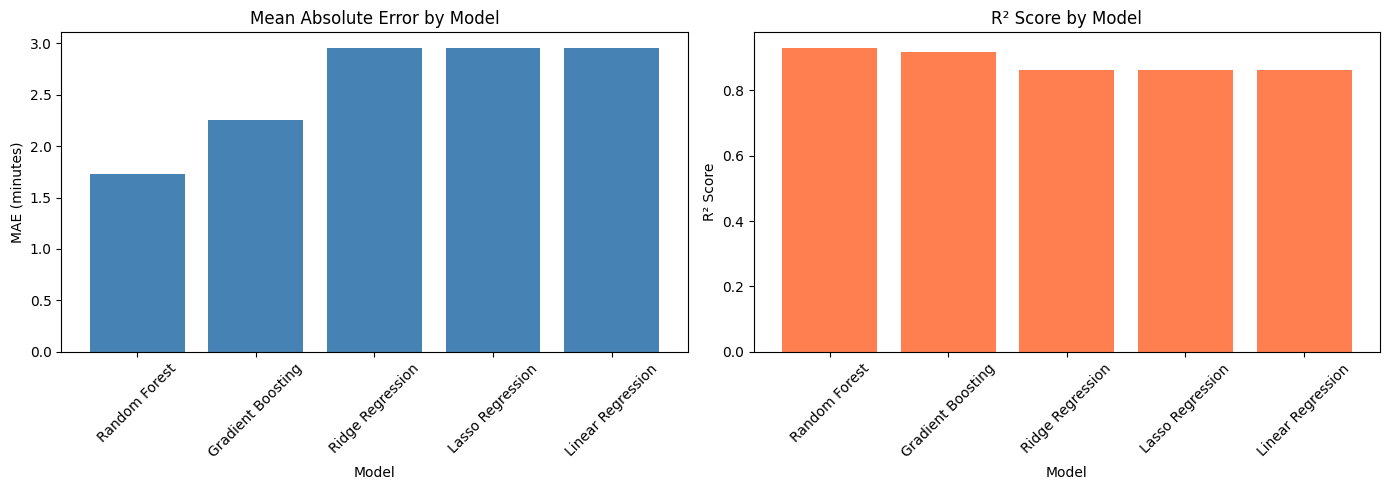

In [14]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
mae_scores = [results[m]['MAE'] for m in model_names]
r2_scores = [results[m]['R2'] for m in model_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

ax1.bar(model_names, mae_scores, color='steelblue')
ax1.set_xlabel('Model')
ax1.set_ylabel('MAE (minutes)')
ax1.set_title('Mean Absolute Error by Model')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(model_names, r2_scores, color='coral')
ax2.set_xlabel('Model')
ax2.set_ylabel('R² Score')
ax2.set_title('R² Score by Model')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [15]:
print("="*60)
print("MODEL TRAINING SUMMARY")
print("="*60)
print(f"Best Model: {best_model_name}")
print(f"Mean Absolute Error: {best_mae:.2f} minutes")
print(f"R² Score: {results[best_model_name]['R2']:.4f}")
print(f"\nModel saved as: best_model.pkl")
print("="*60)

MODEL TRAINING SUMMARY
Best Model: Random Forest
Mean Absolute Error: 1.73 minutes
R² Score: 0.9301

Model saved as: best_model.pkl
